In [13]:
import pandas as pd
import numpy as np
import os
from itertools import product
import matplotlib.pyplot as plt
from statsmodels.regression.recursive_ls import RecursiveLS
from statsmodels.regression.linear_model import OLS

# Data Loading

In [14]:
# Load data
fx_rates_data = pd.read_parquet("../data/fx_rates.parquet")
yields_data = pd.read_parquet("../data/yields.parquet")

# Settings

In [15]:
# Settings
currency_options = ["USD", "EUR", "JPN", "GBP"]
start_date = '1974-10-01'
end_date = '2020-02-01'
x_currencies = currency_options
l_currencies = currency_options
h_currencies = currency_options

# Fixed settings
holding_period: pd.DateOffset = pd.DateOffset(months=1)
reference_maturities: list[int] = list(range(1, 9*12+1))

# Derived quantities
date_list: list[str] = pd.date_range(
    start=pd.to_datetime(arg=start_date),
    end=pd.to_datetime(arg=end_date),
    freq='MS'
).strftime(date_format='%Y-%m-%d').to_list()

# Strategy Simulation

### Data Preprocessing

In [16]:
# Add forward yields
fwd_ylds = yields_data[['date', 'currency', 'maturity', 'yield']].copy()
fwd_ylds['maturity'] = fwd_ylds['maturity'] + holding_period.months
fwd_ylds['date'] = fwd_ylds['date'] - holding_period
yields = yields_data.merge(fwd_ylds, on=['date', 'currency', 'maturity'], suffixes=('', '_1n1'), how='left')
yields['P0n'] = np.exp(-yields['yield'] * yields['maturity'] / 12)
yields['P1n1'] = np.exp(-yields['yield_1n1'] * (yields['maturity'] - holding_period.months ) / 12)

### Unconditional Strategy Simulation

In [17]:
# Compute unconditional strategy data across all combinations of (X, L, H) and maturities

# Store the data in a dictionary of dataframes, where the key is a tuple (X, L, H), and attach the relevant FX and yields
data = []

for (X, L, H) in product(x_currencies, l_currencies, h_currencies):

    # Create base dataframe
    df = pd.DataFrame(
        data=[(X, L, H, i[0], i[1]) for i in list(product(reference_maturities, date_list))],
        columns=['X', 'L', 'H', 'maturity', 't0']
    )
    df['t0'] = pd.to_datetime(df['t0'])
    df['t1'] = df['t0'] + holding_period

    # Attach FX data
    FX0XL = fx_rates_data[fx_rates_data['currencies'] == f'{X}_{L}'][['date', 'fx']].rename(columns={'fx': 'FX0XL', 'date': 't0'})
    FX1XL = fx_rates_data[fx_rates_data['currencies'] == f'{X}_{L}'][['date', 'fx']].rename(columns={'fx': 'FX1XL', 'date': 't1'})
    FX0XH = fx_rates_data[fx_rates_data['currencies'] == f'{X}_{H}'][['date', 'fx']].rename(columns={'fx': 'FX0XH', 'date': 't0'})
    FX1XH = fx_rates_data[fx_rates_data['currencies'] == f'{X}_{H}'][['date', 'fx']].rename(columns={'fx': 'FX1XH', 'date': 't1'})
    df = (
        df
        .merge(FX0XL, on='t0', how='left')
        .merge(FX1XL, on='t1', how='left')
        .merge(FX0XH, on='t0', how='left')
        .merge(FX1XH, on='t1', how='left')
    )

    # Attach yield data
    PL01 = yields[(yields['currency'] == L) & (yields['maturity'] == holding_period.months)][['date', 'P0n']].rename(columns={'P0n': 'PL01', 'date': 't0'})
    PH0n = yields[(yields['currency'] == H)][['date', 'maturity', 'P0n']].rename(columns={'P0n': 'PH0n', 'date': 't0'})
    PH1n1 = yields[(yields['currency'] == H)][['date', 'maturity', 'P1n1']].rename(columns={'P1n1': 'PH1n1', 'date': 't0'})
    PX01 = yields[(yields['currency'] == X) & (yields['maturity'] == holding_period.months)][['date', 'P0n']].rename(columns={'P0n': 'PX01', 'date': 't0'})
    PH01 = yields[(yields['currency'] == H) & (yields['maturity'] == holding_period.months)][['date', 'P0n']].rename(columns={'P0n': 'PH01', 'date': 't0'})

    df = (
        df
        .merge(PL01, on=['t0'], how='left')
        .merge(PH0n, on=['t0', 'maturity'], how='left')
        .merge(PH1n1, on=['t0', 'maturity'], how='left')
        .merge(PX01, on=['t0'], how='left')
        .merge(PH01, on=['t0'], how='left')
    )

    # Compute derived quantities
    df['FFX0_XL1'] = df['FX0XL'] * df['PL01'] / df['PX01']
    df['FPH0n1'] = df['PH0n'] / df['PH01']
    df['FFX0_XH1'] = df['FX0XH'] * df['PH01'] / df['PX01']

    # Compute PnL
    df['PnL'] = - df['FX1XL']  / (df['FX0XL'] * df['PL01']) + df['PH1n1'] * df['FX1XH'] / (df['FX0XH'] * df['PH0n'])
    df['PnL_eq4'] = (1/df['PX01']) * (-df['FX1XL']/df['FFX0_XL1'] + df['PH1n1']/df['FPH0n1'] * df['FX1XH']/df['FFX0_XH1'])

    # Assign to the dictionary
    data.append(df)

# Concatenate all dataframes
data: pd.DataFrame = pd.concat(data, axis=0).reset_index(drop=True)

### Conditional Strategy Simulation

In [18]:
# Simplify averaging across maturities
across_maturity_data = data.groupby(['t0', 'X', 'L', 'H'])[['PnL']].mean().reset_index().sort_values(['t0', 'X', 'L', 'H']).reset_index(drop=True)
across_maturity_data['t1'] = across_maturity_data['t0'] + holding_period
across_maturity_data = across_maturity_data[['t0', 't1', 'X', 'L', 'H', 'PnL']].copy()

# Prepare data for regression
reg_data = across_maturity_data.merge(
    across_maturity_data[['t1', 'X', 'L', 'H', 'PnL']].rename(columns={'t1': 't0', 'PnL': 'PnL_t1'}),
    on=['t0', 'X', 'L', 'H'],
)
reg_data['const'] = 1

# Run regression to estimate beta and gamma
cond_strat_params = []
for (x, l, h) in product(x_currencies, l_currencies, h_currencies):
    curr_reg_data = reg_data[(reg_data['X']==x) & (reg_data['L']==l) & (reg_data['H']==h)].copy().set_index('t1').dropna()
    curr_reg_data.index.freq = 'MS'
    regr_model = OLS(curr_reg_data['PnL'], curr_reg_data[['const', 'PnL_t1']])
    res = regr_model.fit()
    curr_cond_strat_params = res.params.to_frame(name='value').reset_index(names='parameter')
    curr_cond_strat_params['X'] = x
    curr_cond_strat_params['L'] = l
    curr_cond_strat_params['H'] = h
    curr_cond_strat_params = curr_cond_strat_params.pivot(index=['X', 'L', 'H'], columns='parameter', values='value').reset_index()
    cond_strat_params.append(curr_cond_strat_params)
cond_strat_params = pd.concat(cond_strat_params, axis=0).reset_index(drop=True)

# Conditional strategy
cond_strat = reg_data.merge(cond_strat_params, on=['X', 'L', 'H'], how='left', suffixes=('', '_params'))
cond_strat['expected_PnL'] = cond_strat['const_params'] + cond_strat['PnL_t1'] * cond_strat['PnL_t1_params']
cond_strat['cond_strat_PnL'] = cond_strat['PnL'] * cond_strat['expected_PnL']

# Performance Analysis

In [19]:
# Strategy data for all combinations of (X, L, H)
strategy_data = cond_strat[['t0', 't1', 'X', 'L', 'H', 'PnL', 'cond_strat_PnL']].copy().rename(columns={'PnL': 'Unconditional_PnL', 'cond_strat_PnL': 'Conditional_PnL'})

# Compute perf_stats_condormance metrics
perf_stats_cond = pd.merge(
    strategy_data.groupby(['X', 'H', 'L'])[['Conditional_PnL']].mean().reset_index().rename(columns={'Conditional_PnL':'exret'}),
    strategy_data.groupby(['X', 'H', 'L'])[['Conditional_PnL']].std().reset_index().rename(columns={'Conditional_PnL':'std'}),
    on=['X', 'H', 'L']
)
# Set to yearly
perf_stats_cond['exret'] = perf_stats_cond['exret'] * 12 / holding_period.months
perf_stats_cond['std'] = perf_stats_cond['std'] * (12 / holding_period.months) ** 0.5
perf_stats_cond['shape_ratio'] = perf_stats_cond['exret'] / perf_stats_cond['std']

# Excess return of the monthly uncond strategy aggregated
perf_stats_uncond = pd.merge(
    strategy_data.groupby(['X', 'H', 'L'])[['Unconditional_PnL']].mean().reset_index().rename(columns={'Unconditional_PnL':'exret'}),
    strategy_data.groupby(['X', 'H', 'L'])[['Unconditional_PnL']].std().reset_index().rename(columns={'Unconditional_PnL':'std'}),
    on=['X', 'H', 'L']
)
# Set to yearly
perf_stats_uncond['exret'] = perf_stats_uncond['exret'] * 12 / holding_period.months
perf_stats_uncond['std'] = perf_stats_uncond['std'] * (12 / holding_period.months) ** 0.5
perf_stats_uncond['shape_ratio'] = perf_stats_uncond['exret'] / perf_stats_uncond['std']

# Compare the two PnL distributions
compare_perf_stats = perf_stats_uncond.merge(
    perf_stats_cond,
    on=['X', 'H', 'L'],
    suffixes=('_uncond', '_cond')
)
compare_perf_stats['sr_diff'] = compare_perf_stats['shape_ratio_cond'] - compare_perf_stats['shape_ratio_uncond']

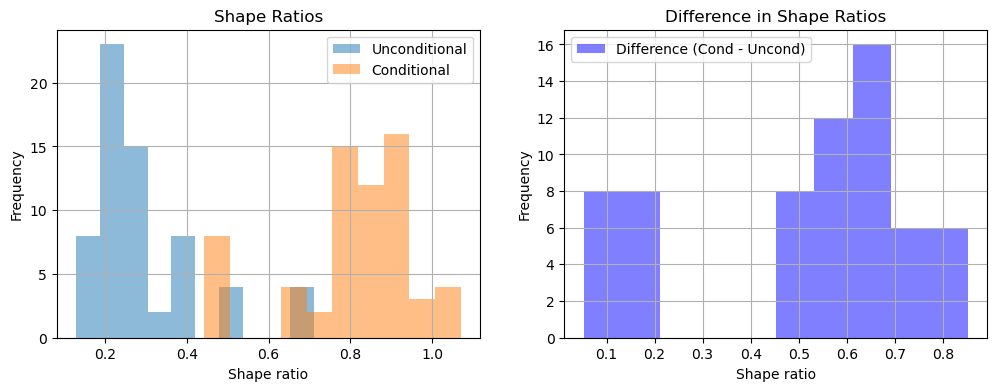

In [20]:
fig1, ax1 = plt.subplots(1, 2, figsize=(12, 4))
compare_perf_stats['shape_ratio_uncond'].plot(kind='hist', ax=ax1[0], alpha=0.5, label='Unconditional')
compare_perf_stats['shape_ratio_cond'].plot(kind='hist', ax=ax1[0], alpha=0.5, label='Conditional')
compare_perf_stats['sr_diff'].plot(kind='hist', ax=ax1[1], alpha=0.5, label='Difference (Cond - Uncond)', color='blue')
ax1[0].set_title('Shape Ratios')
ax1[1].set_title('Difference in Shape Ratios')
ax1[0].set_xlabel('Shape ratio')
ax1[1].set_xlabel('Shape ratio')
ax1[0].legend()
ax1[1].legend()
ax1[0].grid()
ax1[1].grid()
plt.show()

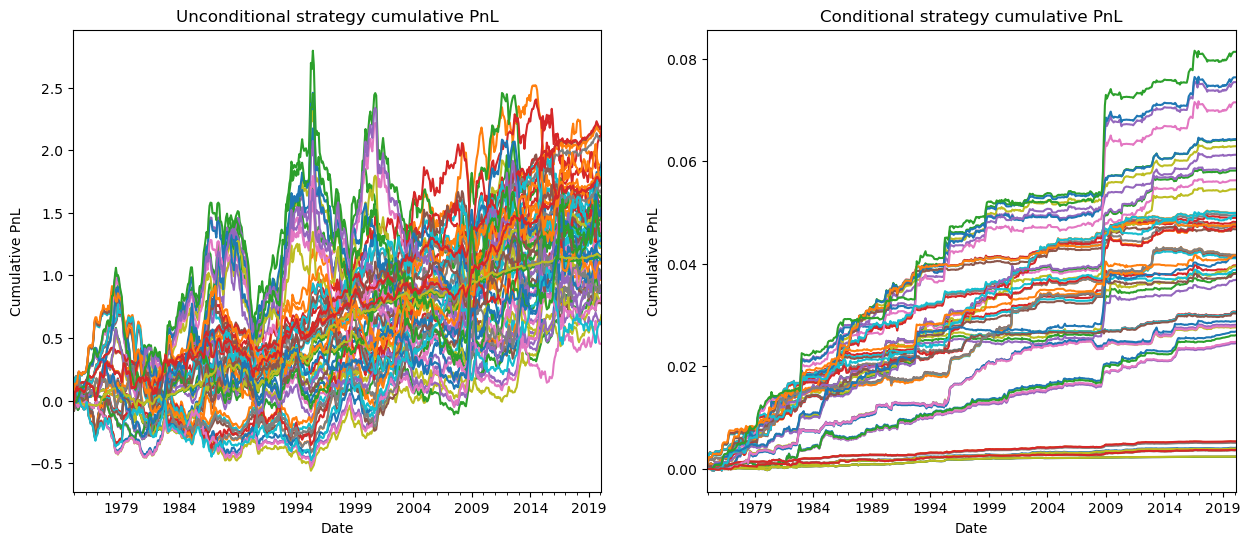

In [21]:
fig3, ax3 = plt.subplots(1, 2, figsize=(15, 6))
for (x1, l1, h1) in product(x_currencies, l_currencies, h_currencies):
    curr_pnls = strategy_data[(strategy_data['X'] == x1) & (strategy_data['L'] == l1) & (strategy_data['H'] == h1)].set_index('t1')[['Unconditional_PnL', 'Conditional_PnL']].dropna()
    curr_pnls = (1+ curr_pnls).cumprod() - 1
    curr_pnls[['Unconditional_PnL']].plot(ax=ax3[0])
    curr_pnls[['Conditional_PnL']].plot(ax=ax3[1])
# Remove legends for individual lines to avoid clutter, and add a single legend for the whole plot
ax3[0].set_title('Unconditional strategy cumulative PnL')
ax3[1].set_title('Conditional strategy cumulative PnL')
ax3[0].set_xlabel('Date')
ax3[0].set_ylabel('Cumulative PnL')
ax3[1].set_xlabel('Date')
ax3[1].set_ylabel('Cumulative PnL')
ax3[0].legend().remove()
ax3[1].legend().remove()
plt.show()